# Quick exploration of recent extragalactic transient candidates

```Author: Francisco Förster, modifications: Kay Medina, Alejandra Muñoz-Arancibia. Last updated: 20260625```

Select recent supernova candidates from the different ALeRCE classifiers using the ALeRCE python client and the ALeRCE Table Access Protocol (TAP) service.

*It is highly recommended that you try this notebook in Google Colab using the following [link](https://colab.research.google.com/github/alercebroker/usecases/blob/master/notebooks/ZTF/ALeRCE_Transients_DESI.ipynb).*
This will avoid you from having to sort out library installation problems and focus on the contents of the tutorial. You can try installing the dependencies later in your own system.

### Load libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io

In [2]:
from astropy.time import Time
from datetime import datetime

ALeRCE client

In [3]:
#!pip install alerce
from alerce.core import Alerce
client = Alerce()

PyVO https://pyvo.readthedocs.io/en/latest/

In [4]:
#!pip install pyvo
import pyvo

### TAP connection setup

Instead of using a direct PostgreSQL connection, we connect to the ALeRCE ZTF legacy database using Astronomical Data Query Language ([ADQL](https://www.ivoa.net/documents/ADQL/)) queries to the ALeRCE TAP service, returning results as pandas dataframes. Database table names are prefixed with `ztf.` (e.g. `ztf.object`, `ztf.detection`, etc.).

In [5]:
import pyvo

TAP_URL = "https://tap.alerce.online/tap"
tap_service = pyvo.dal.TAPService(TAP_URL)

def tap_query(query, maxrec=10_000_000):
    result = tap_service.search(query, maxrec=maxrec)
    return result.to_table().to_pandas()

def tap_query_arraycol(query, maxrec=10_000_000):
    # Use this for tables with ARRAY columns (e.g. ztf.taxonomy.classes):
    # the default VOTable parser rejects DaCHS's arraysize="*x*"
    result = tap_service.create_query(query, maxrec=maxrec, responseformat='csv')
    return pd.read_csv(io.BytesIO(result.execute_stream().read()))

Get table names

In [6]:
query = """
SELECT table_name
FROM TAP_SCHEMA.tables
WHERE schema_name = 'ztf'
ORDER BY table_name
"""
tables = tap_query(query)
tables

,table_name
0,ztf.allwise
1,ztf.dataquality
2,ztf.detection
3,ztf.feature
4,ztf.feature_version
5,ztf.forced_photometry
6,ztf.gaia_ztf
7,ztf.magstat
8,ztf.non_detection
9,ztf.object


Get all column names for every table

In [7]:
alltabs = []
for tab in sorted(tables.table_name):
    query = f"""
SELECT column_name, datatype
FROM TAP_SCHEMA.columns
WHERE table_name = '{tab}'
ORDER BY column_name
"""
    results = tap_query(query)
    results["table"] = tab
    alltabs.append(results)
dftab = pd.concat(alltabs)
pd.options.display.max_rows = 999
display(dftab[["table", "column_name", "datatype"]])
pd.options.display.max_rows = 101

,table,column_name,datatype
0,ztf.allwise,dec,double
1,ztf.allwise,h_m_2mass,double
2,ztf.allwise,h_msig_2mass,double
3,ztf.allwise,j_m_2mass,double
4,ztf.allwise,j_msig_2mass,double
5,ztf.allwise,k_m_2mass,double
6,ztf.allwise,k_msig_2mass,double
7,ztf.allwise,oid_catalog,char
8,ztf.allwise,ra,double
9,ztf.allwise,w1mpro,double


Show the taxonomy for the different classifiers

In [8]:
query = "SELECT * FROM ztf.taxonomy ORDER BY classifier_name"
classes = tap_query_arraycol(query)
classes

,classifier_name,classifier_version,classes
0,lc_classifier,hierarchical_random_forest_1.0.0,"['SNIa', 'SNIbc', 'SNII', 'SLSN', 'QSO', 'AGN'..."
1,LC_classifier_ATAT_forced_phot(beta),beta,"['SNIa', 'SNIbc', 'SNIIb', 'SNII', 'SNIIn', 'S..."
2,lc_classifier_BHRF_forced_phot,2.1.0,"['SNIa', 'SESN', 'SNII', 'SNIIn', 'SLSN', 'TDE..."
3,LC_classifier_BHRF_forced_phot(beta),beta,"['SNIa', 'SNIbc', 'SNIIb', 'SNII', 'SNIIn', 'S..."
4,lc_classifier_BHRF_forced_phot_periodic,2.1.0,"['LPV', 'EA', 'EB/EW', 'Periodic-Other', 'RSCV..."
5,lc_classifier_BHRF_forced_phot_stochastic,2.1.0,"['Microlensing', 'QSO', 'AGN', 'Blazar', 'YSO'..."
6,lc_classifier_BHRF_forced_phot_top,2.1.0,"['Transient', 'Stochastic', 'Periodic']"
7,lc_classifier_BHRF_forced_phot_transient,2.1.0,"['SNIa', 'SESN', 'SNII', 'SNIIn', 'SLSN', 'TDE']"
8,lc_classifier_periodic,hierarchical_random_forest_1.0.0,"['LPV', 'E', 'DSCT', 'RRL', 'CEP', 'Periodic-O..."
9,lc_classifier_stochastic,hierarchical_random_forest_1.0.0,"['QSO', 'AGN', 'Blazar', 'CV/Nova', 'YSO']"


# Classifier transient classes and recommended classifier versions

In [9]:
# classifier taxonomies
transients = {}
transients["stamp_classifier"] = ["SN", "AGN"] # we include AGN because they might be TDEs
transients["lc_classifier"] = ['SNIa', 'SNIbc', 'SNII', 'SLSN']
transients["lc_classifier_BHRF_forced_phot"] = ['SNIa', 'SESN', 'SNII', 'SNIIn', 'SLSN', 'TDE']
transients["LC_classifier_ATAT_forced_phot(beta)"] = ['SNIa', 'SNIbc', 'SNII', 'SNIIn', 'SLSN', 'TDE']

# confirm with the ALeRCE team about the recommended version
classifier_version = {}
classifier_version["stamp_classifier"] = "stamp_classifier_1.0.4"
classifier_version["lc_classifier"] = "lc_classifier_1.1.13"
classifier_version["lc_classifier_BHRF_forced_phot"] = "2.1.0"
classifier_version["LC_classifier_ATAT_forced_phot(beta)"] = "1.0.0"

### Query objects that appeared during the last two days, that are classified as most likely supernova or AGN by the stamp classifier with a probability larger than 0.4

In [10]:
ndays = 2
mjd_last = Time(datetime.utcnow(), scale='utc').mjd - ndays

sn = {}

query = '''
SELECT
    o.oid, o.meanra, o.meandec, o.firstmjd,
    o.ndet, o.stellar, p.probability,
    p.classifier_name, p.classifier_version,
    p.class_name
FROM
    ztf.object AS o
INNER JOIN
    ztf.probability AS p
ON
    o.oid = p.oid
WHERE
    o.firstmjd > %s
    AND p.classifier_name = 'stamp_classifier'
    AND p.class_name IN (%s)
    AND p.ranking = 1
    AND p.probability > 0.4
''' % (mjd_last, ",".join([f"'{i}'" for i in transients["stamp_classifier"]]))

sn["stamp_classifier"] = tap_query(query)
sn["stamp_classifier"].set_index('oid', inplace=True)
print(sn['stamp_classifier'].shape)
sn["stamp_classifier"].head()

(124, 9)


,meanra,meandec,firstmjd,ndet,stellar,probability,classifier_name,classifier_version,class_name
oid,,,,,,,,,
ZTF26abdspgh,260.806607,-8.939052,61215.298981,1,False,0.417432,stamp_classifier,stamp_classifier_1.0.4,AGN
ZTF19abchnsu,257.851849,-16.718624,61215.299456,1,False,0.427835,stamp_classifier,stamp_classifier_1.0.4,AGN
ZTF26abdsrdr,253.718182,-16.367497,61215.299456,1,False,0.416196,stamp_classifier,stamp_classifier_1.0.4,AGN
ZTF26abdspmh,253.482855,-9.479140,61215.300405,1,False,0.435285,stamp_classifier,stamp_classifier_1.0.4,AGN
ZTF26abdsqka,249.720593,-8.832862,61215.300405,1,False,0.442972,stamp_classifier,stamp_classifier_1.0.4,AGN


Plot a histogram of discovery dates

Text(0.5, 0, 'firstmjd')

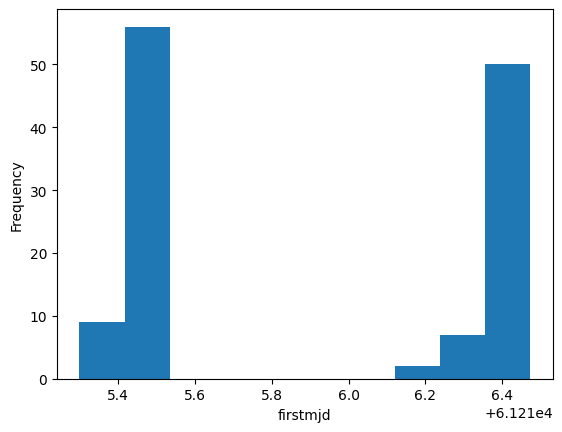

In [11]:
fig, ax = plt.subplots()
sn["stamp_classifier"].firstmjd.plot.hist(ax=ax)
ax.set_xlabel("firstmjd")

Bar plot of classes

<Axes: ylabel='class_name'>

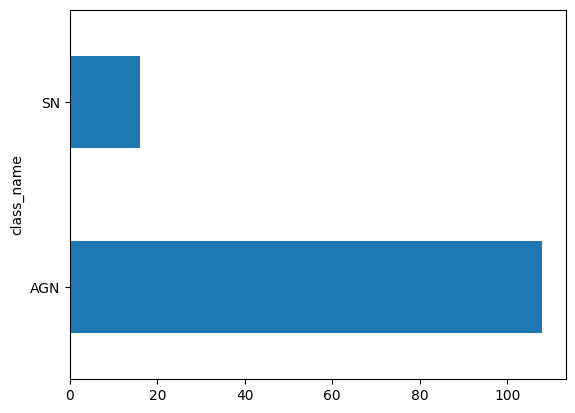

In [12]:
sn["stamp_classifier"].class_name.value_counts().plot.barh()

Plot histograms of probabilities divided by class

Text(0.5, 0, 'probability')

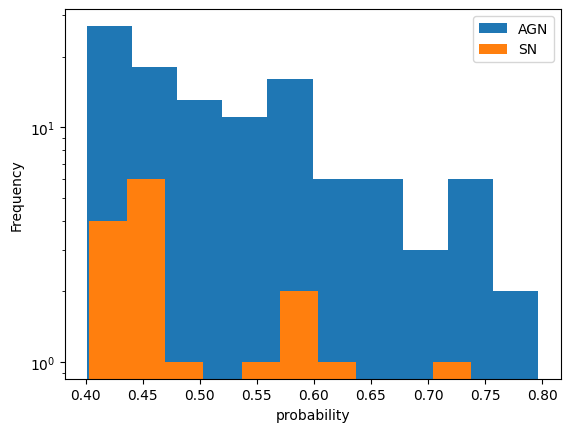

In [13]:
fig, ax = plt.subplots()
for class_name, grp in sn["stamp_classifier"].groupby("class_name"):
    grp.probability.plot.hist(label=class_name, log=True, legend=True, ax=ax)
ax.set_xlabel("probability")

#  Query objects that appeared during the last month, that are classified as most likely transient by any of the the light curve classifiers

Check the classifier and class names

In [14]:
print(classes.loc[classes.classifier_name=="lc_classifier"].classes.to_list())
print(classes.loc[classes.classifier_name=="lc_classifier_BHRF_forced_phot"].classes.to_list())
print(classes.loc[classes.classifier_name=="LC_classifier_ATAT_forced_phot(beta)"].classes.to_list())

["['SNIa', 'SNIbc', 'SNII', 'SLSN', 'QSO', 'AGN', 'Blazar', 'CV/Nova', 'YSO', 'LPV', 'E', 'DSCT', 'RRL', 'CEP', 'Periodic-Other']"]
["['SNIa', 'SESN', 'SNII', 'SNIIn', 'SLSN', 'TDE', 'Microlensing', 'QSO', 'AGN', 'Blazar', 'YSO', 'CV/Nova', 'LPV', 'EA', 'EB/EW', 'Periodic-Other', 'RSCVn', 'CEP', 'RRLab', 'RRLc', 'DSCT']"]
["['SNIa', 'SNIbc', 'SNIIb', 'SNII', 'SNIIn', 'SLSN', 'TDE', 'Microlensing', 'QSO', 'AGN', 'Blazar', 'YSO', 'CV/Nova', 'LPV', 'EA', 'EB/EW', 'Periodic-Other', 'RSCVn', 'CEP', 'RRLab', 'RRLc', 'DSCT']"]


Query by classifier, this time we will require at least six detections since old versions of the forced photometry classifiers can be applied with even 2 detections and lc_classifier requires at least six detections in the same band.

In [15]:
ndays = 30
mjd_last = Time(datetime.utcnow(), scale='utc').mjd - ndays

for clf in ["lc_classifier", "lc_classifier_BHRF_forced_phot", "LC_classifier_ATAT_forced_phot(beta)"]:
    query = f'''
    SELECT
        o.oid, o.meanra, o.meandec, o.firstmjd,
        o.ndet, o.stellar, p.classifier_name, p.classifier_version,
        p.class_name, p.probability
    FROM
        ztf.object AS o
    INNER JOIN
        ztf.probability AS p
    ON
        o.oid = p.oid
    WHERE
        o.firstmjd > {mjd_last}
        AND p.classifier_name = '{clf}'
        AND p.class_name IN ({",".join([f"'{i}'" for i in transients[clf]])})
        AND p.ranking = 1
        AND p.classifier_version = '{classifier_version[clf]}'
        AND o.ndet > 5
    '''
    print(query)
    sn[clf] = tap_query(query)
    sn[clf].set_index('oid', inplace=True)
    print(sn[clf].shape)
    display(sn[clf].head())


    SELECT
        o.oid, o.meanra, o.meandec, o.firstmjd,
        o.ndet, o.stellar, p.classifier_name, p.classifier_version,
        p.class_name, p.probability
    FROM
        ztf.object AS o
    INNER JOIN
        ztf.probability AS p
    ON
        o.oid = p.oid
    WHERE
        o.firstmjd > 61187.04651526955
        AND p.classifier_name = 'lc_classifier'
        AND p.class_name IN ('SNIa','SNIbc','SNII','SLSN')
        AND p.ranking = 1
        AND p.classifier_version = 'lc_classifier_1.1.13'
        AND o.ndet > 5
    
(151, 9)


,meanra,meandec,firstmjd,ndet,stellar,classifier_name,classifier_version,class_name,probability
oid,,,,,,,,,
ZTF26aayznab,8.736210,7.558363,61191.473206,9,False,lc_classifier,lc_classifier_1.1.13,SNIa,0.322164
ZTF26aayzmff,8.993496,10.405428,61191.474641,16,False,lc_classifier,lc_classifier_1.1.13,SNII,0.293112
ZTF20abrclvl,8.797844,-0.821623,61192.471632,8,False,lc_classifier,lc_classifier_1.1.13,SNII,0.224824
ZTF17aaeaeon,8.551848,-1.531879,61192.471632,7,False,lc_classifier,lc_classifier_1.1.13,SNIa,0.148656
ZTF26aazhxtc,3.775316,10.701611,61192.464549,21,False,lc_classifier,lc_classifier_1.1.13,SNII,0.307384



    SELECT
        o.oid, o.meanra, o.meandec, o.firstmjd,
        o.ndet, o.stellar, p.classifier_name, p.classifier_version,
        p.class_name, p.probability
    FROM
        ztf.object AS o
    INNER JOIN
        ztf.probability AS p
    ON
        o.oid = p.oid
    WHERE
        o.firstmjd > 61187.04651526955
        AND p.classifier_name = 'lc_classifier_BHRF_forced_phot'
        AND p.class_name IN ('SNIa','SESN','SNII','SNIIn','SLSN','TDE')
        AND p.ranking = 1
        AND p.classifier_version = '2.1.0'
        AND o.ndet > 5
    
(241, 9)


,meanra,meandec,firstmjd,ndet,stellar,classifier_name,classifier_version,class_name,probability
oid,,,,,,,,,
ZTF26aayzlih,353.090083,9.561767,61191.470312,21,False,lc_classifier_BHRF_forced_phot,2.1.0,SNIa,0.475048
ZTF26aayznab,8.736210,7.558363,61191.473206,9,False,lc_classifier_BHRF_forced_phot,2.1.0,TDE,0.253840
ZTF26aayznam,16.955957,41.995391,61191.477060,9,False,lc_classifier_BHRF_forced_phot,2.1.0,SNIa,0.276864
ZTF26aayzmff,8.993496,10.405428,61191.474641,16,False,lc_classifier_BHRF_forced_phot,2.1.0,SNII,0.212792
ZTF26aayzmoi,7.972945,16.246674,61191.475104,24,False,lc_classifier_BHRF_forced_phot,2.1.0,SLSN,0.200600



    SELECT
        o.oid, o.meanra, o.meandec, o.firstmjd,
        o.ndet, o.stellar, p.classifier_name, p.classifier_version,
        p.class_name, p.probability
    FROM
        ztf.object AS o
    INNER JOIN
        ztf.probability AS p
    ON
        o.oid = p.oid
    WHERE
        o.firstmjd > 61187.04651526955
        AND p.classifier_name = 'LC_classifier_ATAT_forced_phot(beta)'
        AND p.class_name IN ('SNIa','SNIbc','SNII','SNIIn','SLSN','TDE')
        AND p.ranking = 1
        AND p.classifier_version = '1.0.0'
        AND o.ndet > 5
    
(246, 9)


,meanra,meandec,firstmjd,ndet,stellar,classifier_name,classifier_version,class_name,probability
oid,,,,,,,,,
ZTF26aayysyv,269.427752,-2.141004,61191.367847,53,False,LC_classifier_ATAT_forced_phot(beta),1.0.0,SNIbc,0.531811
ZTF26aayzlih,353.090083,9.561767,61191.470312,21,False,LC_classifier_ATAT_forced_phot(beta),1.0.0,SNIa,0.848593
ZTF26aayznab,8.736210,7.558363,61191.473206,9,False,LC_classifier_ATAT_forced_phot(beta),1.0.0,SNIa,0.845971
ZTF26aayznam,16.955957,41.995391,61191.477060,9,False,LC_classifier_ATAT_forced_phot(beta),1.0.0,SNIa,0.832204
ZTF26aayzmff,8.993496,10.405428,61191.474641,16,False,LC_classifier_ATAT_forced_phot(beta),1.0.0,SLSN,0.977170


Plot a ECDF of discovery dates

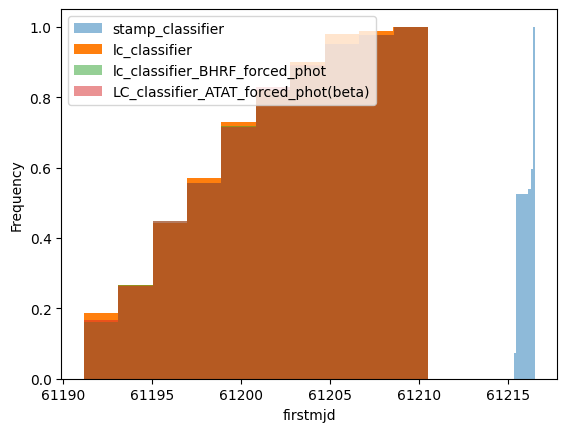

In [16]:
fig, ax = plt.subplots()
for key in sn.keys():
    if sn[key].empty:
        print(f"{key}: no objects matched, skipping")
        continue
    alpha = 0.5
    if key == "lc_classifier":
        alpha = 1
    sn[key].firstmjd.plot.hist(ax=ax, alpha=alpha, cumulative=True, density=True, label=key)
    ax.set_xlabel("firstmjd")
    plt.legend()

Bar plot of classes per classifier

stamp_classifier
lc_classifier
lc_classifier_BHRF_forced_phot
LC_classifier_ATAT_forced_phot(beta)


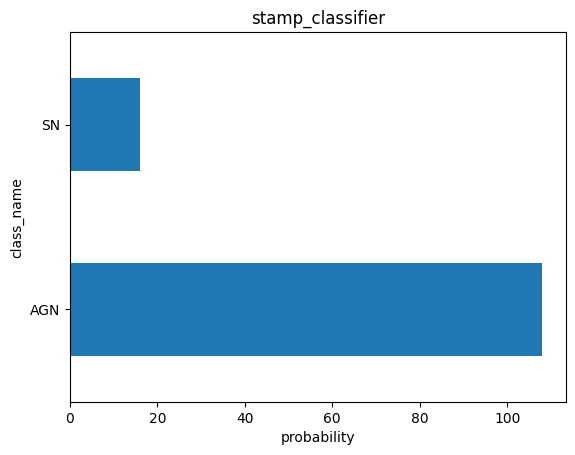

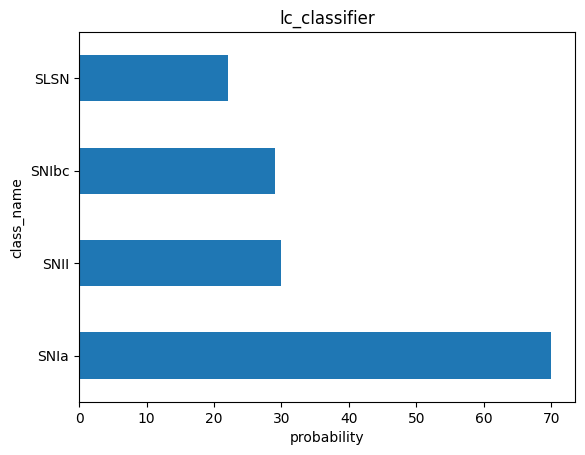

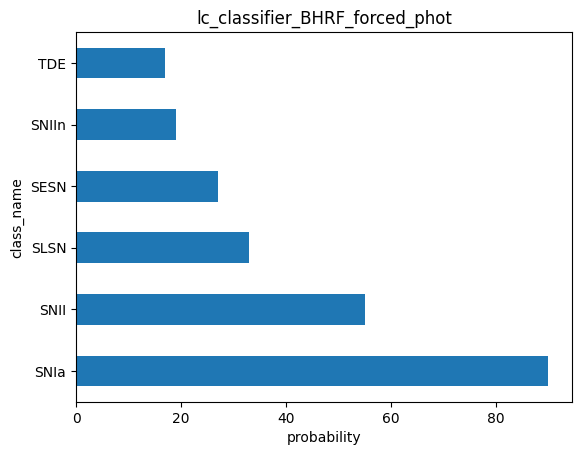

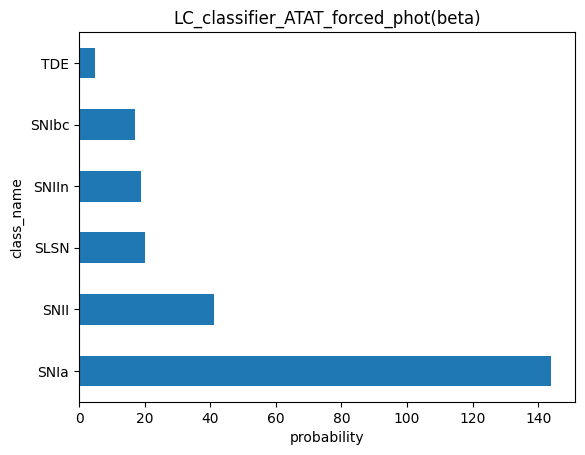

In [17]:
for key in sn.keys():
    print(key)
    if sn[key].empty:
        print(f"{key}: no objects matched — skipping")
        continue
    fig, ax = plt.subplots()
    sn[key].class_name.value_counts().plot.barh()
    ax.set_xlabel("probability")
    ax.set_title(key)

stamp_classifier
lc_classifier
lc_classifier_BHRF_forced_phot
LC_classifier_ATAT_forced_phot(beta)


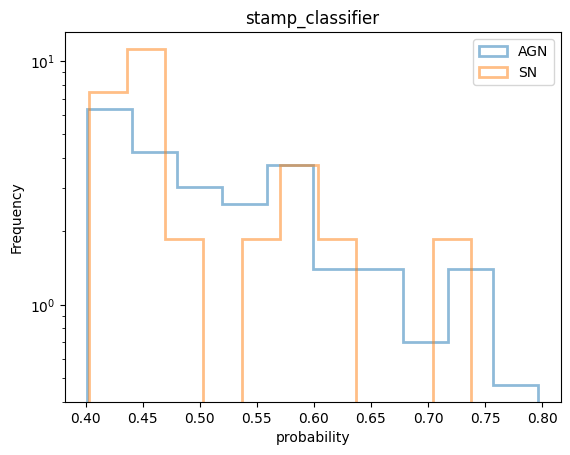

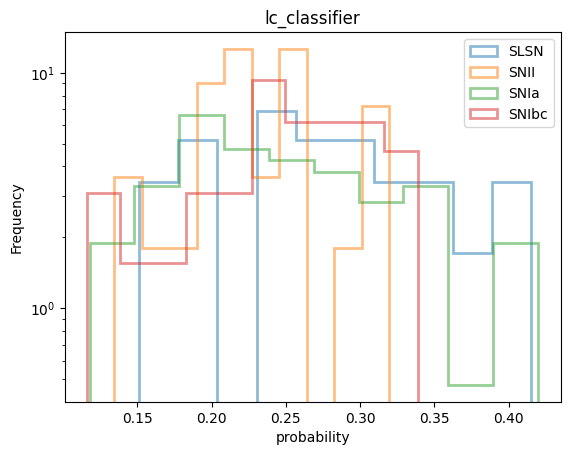

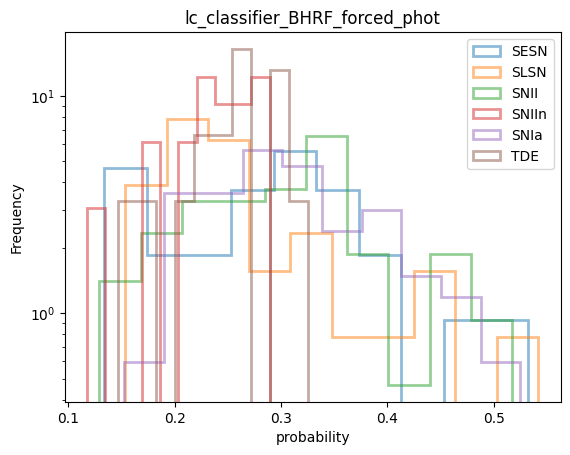

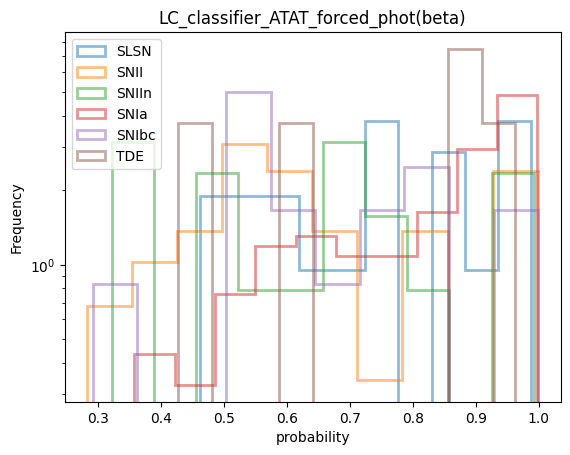

In [18]:
for key in sn.keys():
    print(key)
    if sn[key].empty:
        print(f"{key}: no objects matched — skipping")
        continue
    fig, ax = plt.subplots()
    for class_name, grp in sn[key].groupby("class_name"):
        grp.probability.plot.hist(label=class_name, alpha=0.5, log=True,
                                  legend=True, density=True, histtype='step',
                                  lw=2, ax=ax)
    ax.set_xlabel("probability")
    ax.set_title(key)

Note that the probability distributions are very different between classifiers

# Generate link to quickly inspect all the candidates, starting with the top N most likely given a class

In [19]:
def dourlbatches(df, classifier_name, class_name, N):
    sel = df.loc[df.class_name==class_name].sort_values(by="probability").iloc[::-1].iloc[:N]
    batchsize = 100
    print(f"Classifier: {classifier_name}\nClass: {class_name}\n#events: {sel.shape[0]} (show top {min(N, sel.shape[0])} in batches of not more than {min(batchsize, sel.shape[0])} elements)")
    for ibatch in range(int(np.ceil((sel.shape[0]/batchsize)))):
        print(f"Batch {ibatch + 1}")
        suffix = f"&count=true&page=1&perPage=1000&sortDesc=true&selectedClassifier={classifier_name}"
        url = "https://alerce.online/?" + "&".join(
            "oid=%s" % i for i in sel.iloc[ibatch * batchsize: (ibatch + 1) * batchsize].index) + suffix
        print(url)

Let's remind us about the different classifiers and the transient classes in each of them.

In [20]:
transients

{'stamp_classifier': ['SN', 'AGN'],
 'lc_classifier': ['SNIa', 'SNIbc', 'SNII', 'SLSN'],
 'lc_classifier_BHRF_forced_phot': ['SNIa',
  'SESN',
  'SNII',
  'SNIIn',
  'SLSN',
  'TDE'],
 'LC_classifier_ATAT_forced_phot(beta)': ['SNIa',
  'SNIbc',
  'SNII',
  'SNIIn',
  'SLSN',
  'TDE']}

In [21]:
classifier_name = "lc_classifier_BHRF_forced_phot"
class_name = "TDE"
topN = 25
dourlbatches(sn[classifier_name], classifier_name, class_name, topN)

Classifier: lc_classifier_BHRF_forced_phot
Class: TDE
#events: 17 (show top 17 in batches of not more than 17 elements)
Batch 1
https://alerce.online/?oid=ZTF26abbwvnd&oid=ZTF20abrclvl&oid=ZTF26aazejjc&oid=ZTF26abcsvfc&oid=ZTF26aafibwc&oid=ZTF26aaorcbz&oid=ZTF26abcfire&oid=ZTF26abbhjuu&oid=ZTF19abjarri&oid=ZTF26aayznab&oid=ZTF26abasqzj&oid=ZTF26abbdipw&oid=ZTF26abbwgbo&oid=ZTF26abatkag&oid=ZTF26abacroj&oid=ZTF18aceadxa&oid=ZTF26abchgdc&count=true&page=1&perPage=1000&sortDesc=true&selectedClassifier=lc_classifier_BHRF_forced_phot


In [22]:
classifier_name = "LC_classifier_ATAT_forced_phot(beta)"
class_name = "SNIa"
topN = 200
dourlbatches(sn[classifier_name], classifier_name, class_name, topN)

Classifier: LC_classifier_ATAT_forced_phot(beta)
Class: SNIa
#events: 144 (show top 144 in batches of not more than 100 elements)
Batch 1
https://alerce.online/?oid=ZTF26abanuur&oid=ZTF26aazpizm&oid=ZTF26abbnmch&oid=ZTF26abamcic&oid=ZTF26abbazdw&oid=ZTF26aazexdl&oid=ZTF26abcxvui&oid=ZTF26aazjcyz&oid=ZTF26abdqbqw&oid=ZTF26abauoej&oid=ZTF26abasqzj&oid=ZTF26abamsiv&oid=ZTF26abcfltk&oid=ZTF26aazxion&oid=ZTF26abbkkey&oid=ZTF26aazwidp&oid=ZTF26abaodgr&oid=ZTF26abafqvq&oid=ZTF26aazzumw&oid=ZTF26aazjbed&oid=ZTF26abasxvg&oid=ZTF26aazewrk&oid=ZTF26abamdcg&oid=ZTF26abaztcb&oid=ZTF26abbbfyt&oid=ZTF26abafxlk&oid=ZTF26abajoiu&oid=ZTF26aazwsav&oid=ZTF26abaohdg&oid=ZTF26aayzmoi&oid=ZTF26aazjyhl&oid=ZTF26abbwgbo&oid=ZTF26abbkttb&oid=ZTF26abatghd&oid=ZTF26aaztkuj&oid=ZTF26aazpzma&oid=ZTF26abcibmm&oid=ZTF26abaodln&oid=ZTF26abaztri&oid=ZTF26abatnxt&oid=ZTF26abafnsz&oid=ZTF26abbzdgn&oid=ZTF26abbluiq&oid=ZTF26abchrib&oid=ZTF26abbgnzo&oid=ZTF26aazenpt&oid=ZTF26abbdipw&oid=ZTF26abcccsl&oid=ZTF26abbkeen&oid=ZT

Note that objetcs that have been classified by the same classifier, but with different versions, will appear repeated in the Explorer list